In [1]:
import zipfile
import os

# Colab'ga yuklangan ZIP fayllarni ko'ramiz
zip_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith(".zip")
]

print("ZIP files found:")
for f in zip_files:
    print("📦", f)

ZIP files found:
📦 aoroa_aiml_assignment_2026.zip


In [2]:
zip_path = f"/content/{zip_files[0]}"
extract_path = "/content/aoroa_assignment"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP extracted successfully!")

✅ ZIP extracted successfully!


In [3]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    📄 {file}")

📁 aoroa_assignment/
    📁 aoroa_aiml_assignment_2026/
        📄 requirements.txt
        📄 README.md
        📁 part2_model/
            📁 data/
                📄 ecommerce_events.csv
                📄 forecast_target_dates.csv
                📄 DATA_CARD.md


In [4]:
dataset_path = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file == "ecommerce_events.csv":
            dataset_path = os.path.join(root, file)

print("Dataset path:")
print(dataset_path)

Dataset path:
/content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model/data/ecommerce_events.csv


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(dataset_path)

print("=== DATASET VERIFICATION ===")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Users:", df["user_id"].nunique())
print("Date:", df["date"].min(), "→", df["date"].max())

print("\nColumns:")
print(df.columns.tolist())

=== DATASET VERIFICATION ===
Rows: 72573
Columns: 6
Users: 800
Date: 2022-07-01 → 2024-06-02

Columns:
['date', 'user_id', 'payment_method', 'discount_rate', 'app_time_min', 'paid_amount']


In [10]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

base = "/content/drive/MyDrive"

print("=== MyDrive ===")

for item in os.listdir(base):
    print("📁" if os.path.isdir(os.path.join(base, item)) else "📄", item)

=== MyDrive ===
📁 Colab Notebooks
📁 Saved from the Google app
📄 A Comprehensive Survey on Applications of Transformers for Deep Learning Tasks.gslides
📄 FedMRI_Presentation_Tojiboev_Ikromjon.gslides
📄 Explainable Artificial Intelligence (XAI) 2.0_ A Manifesto of Open Challenges and Research Directions.gslides
📄 Thesis_Plan_Tojiboev_Ikromjon_v1.gdoc
📄 MY THESIS PLAN_논문작성계획서.gdoc
📄 Chest L-Transformer_ Local Features With Position Attention for Weakly Supervised Chest Radiograph Segmentation and Classification.gslides
📄 Untitled document.gdoc
📁 PlantVillage
📄 3. [논문] [Sample] ENG_template.gdoc
📄 plant_model.h5
📄 plant_model.keras
📄 Prototyping presentation.gslides
📄 Case study.gslides
📄 Science project.gslides
📄 Consulting proposal (1).gslides
📄 Recipe book.gslides
📄 Consulting proposal.gslides
📄 Plant_Disease_Presentation_Speech.gdoc
📄 An_Ensemble_Hybrid_Framework_A_Comparative_Analysis_of_Metaheuristic_Algorithms_for_Ensemble_Hybrid_CNN_Features_for_Plants_Disease_Class

In [15]:
project_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"

print("\n=== AOROA PROJECT ===")

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    📄 {file}")


=== AOROA PROJECT ===
📁 AOROA_Labs_Assignment/
    📄 experiment_log.md
    📁 data/
    📁 results/
        📄 baseline_validation_results.csv
        📄 baseline_weekday_means.csv
        📄 data_audit.csv
        📄 missing_values.csv
        📄 eda_statistics.csv
        📄 weekday_eda.csv
        📄 daily_sales.csv
    📁 figures/
    📁 reports/
        📄 EDA_Findings_Assumptions.md
    📁 src/


In [16]:
# ==========================================
# RESTORE DAY 1 RESULTS
# ==========================================

import pandas as pd
import numpy as np
import os

project_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"
results_dir = f"{project_dir}/results"

# Daily sales
daily_sales = pd.read_csv(
    f"{results_dir}/daily_sales.csv"
)

# Official baseline
baseline_weekday_means = pd.read_csv(
    f"{results_dir}/baseline_weekday_means.csv"
)

baseline_validation = pd.read_csv(
    f"{results_dir}/baseline_validation_results.csv"
)

print("=== RESTORED DAY 1 RESULTS ===")
print(f"Daily sales:              {daily_sales.shape}")
print(f"Baseline weekday means:   {baseline_weekday_means.shape}")
print(f"Baseline validation:      {baseline_validation.shape}")

=== RESTORED DAY 1 RESULTS ===
Daily sales:              (703, 2)
Baseline weekday means:   (7, 2)
Baseline validation:      (28, 6)


In [17]:
# ==========================================
# FIND ORIGINAL DATASET
# ==========================================

dataset_path = None

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "ecommerce_events.csv":
            dataset_path = os.path.join(root, file)
            break

print("Dataset path:")
print(dataset_path)

Dataset path:
/content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model/data/ecommerce_events.csv


In [18]:
df = pd.read_csv(dataset_path)

print("\n=== DATASET VERIFICATION ===")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique users:", df["user_id"].nunique())
print("Date:", df["date"].min(), "→", df["date"].max())


=== DATASET VERIFICATION ===
Rows: 72573
Columns: 6
Unique users: 800
Date: 2022-07-01 → 2024-06-02


In [19]:
# ==========================================
# DAY 2 — STEP 1
# PREPARE TRANSACTION DATA
# ==========================================

df["date"] = pd.to_datetime(df["date"])

print("Date dtype:", df["date"].dtype)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Transactions:", len(df))
print("Users:", df["user_id"].nunique())

Date dtype: datetime64[ns]
Date range: 2022-07-01 00:00:00 → 2024-06-02 00:00:00
Transactions: 72573
Users: 800


In [20]:
# ==========================================
# REFERENCE DATE
# ==========================================

reference_date = df["date"].max()

print("Reference date:", reference_date)

Reference date: 2024-06-02 00:00:00


In [21]:
# ==========================================
# RFM FEATURES
# ==========================================

customer_features = (
    df.groupby("user_id")
      .agg(
          last_purchase_date=("date", "max"),
          frequency=("user_id", "size"),
          monetary=("paid_amount", "sum"),
          avg_transaction_value=("paid_amount", "mean"),
          avg_discount_rate=("discount_rate", "mean"),
          avg_app_time_min=("app_time_min", "mean")
      )
      .reset_index()
)

customer_features["recency_days"] = (
    reference_date - customer_features["last_purchase_date"]
).dt.days

print("Customer-level dataset created!")
print("Customers:", len(customer_features))
print("Features:", len(customer_features.columns))

display(customer_features.head())

Customer-level dataset created!
Customers: 800
Features: 8


,user_id,last_purchase_date,frequency,monetary,avg_transaction_value,avg_discount_rate,avg_app_time_min,recency_days
0,U0000,2024-05-23,80,4732976,59162.200000,0.017500,16.712500,10
1,U0001,2024-05-14,130,11387193,87593.792308,0.020000,32.069231,19
2,U0002,2024-05-29,75,4777219,63696.253333,0.023333,7.293333,4
3,U0003,2024-05-23,104,4514605,43409.663462,0.020673,12.028846,10
4,U0004,2024-05-30,100,4537931,45379.310000,0.140500,7.740000,3


In [22]:
# ==========================================
# PAYMENT METHOD FEATURE
# ==========================================

df["payment_method_clean"] = (
    df["payment_method"]
    .fillna("Unknown")
)

payment_counts = (
    df.groupby("user_id")["payment_method_clean"]
      .nunique()
      .reset_index(name="payment_method_count")
)

customer_features = customer_features.merge(
    payment_counts,
    on="user_id",
    how="left"
)

display(customer_features.head())

,user_id,last_purchase_date,frequency,monetary,avg_transaction_value,avg_discount_rate,avg_app_time_min,recency_days,payment_method_count
0,U0000,2024-05-23,80,4732976,59162.200000,0.017500,16.712500,10,5
1,U0001,2024-05-14,130,11387193,87593.792308,0.020000,32.069231,19,5
2,U0002,2024-05-29,75,4777219,63696.253333,0.023333,7.293333,4,5
3,U0003,2024-05-23,104,4514605,43409.663462,0.020673,12.028846,10,5
4,U0004,2024-05-30,100,4537931,45379.310000,0.140500,7.740000,3,5


In [23]:
print("=== CUSTOMER FEATURES ===")

print(customer_features.columns.tolist())

print("\nShape:")
print(customer_features.shape)

print("\nMissing values:")
display(customer_features.isna().sum().to_frame("missing"))

=== CUSTOMER FEATURES ===
['user_id', 'last_purchase_date', 'frequency', 'monetary', 'avg_transaction_value', 'avg_discount_rate', 'avg_app_time_min', 'recency_days', 'payment_method_count']

Shape:
(800, 9)

Missing values:


,missing
user_id,0
last_purchase_date,0
frequency,0
monetary,0
avg_transaction_value,0
avg_discount_rate,0
avg_app_time_min,0
recency_days,0
payment_method_count,0


In [24]:
# ==========================================
# SAVE CUSTOMER FEATURES
# ==========================================

customer_features_path = (
    f"{project_dir}/results/customer_features_raw.csv"
)

customer_features.to_csv(
    customer_features_path,
    index=False
)

print("✅ Customer features saved!")
print(customer_features_path)
print("Shape:", customer_features.shape)

✅ Customer features saved!
/content/drive/MyDrive/AOROA_Labs_Assignment/results/customer_features_raw.csv
Shape: (800, 9)


In [25]:
print(
    os.path.exists(customer_features_path)
)

True


In [26]:
# ==========================================
# CUSTOMER FEATURE STATISTICS
# ==========================================

feature_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_transaction_value",
    "avg_discount_rate",
    "avg_app_time_min",
    "payment_method_count"
]

customer_features[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
recency_days,800.0,2.249875e+01,5.785492e+01,0.000000,1.000000e+00,4.000000e+00,1.000000e+01,4.320000e+02
frequency,800.0,9.071625e+01,2.279227e+01,23.000000,8.200000e+01,9.100000e+01,1.000000e+02,1.590000e+02
monetary,800.0,4.963071e+06,3.030611e+06,783297.000000,3.040245e+06,4.155000e+06,5.739722e+06,2.412703e+07
avg_transaction_value,800.0,5.347252e+04,2.237284e+04,15131.119048,3.708647e+04,4.961945e+04,6.424067e+04,1.884924e+05
avg_discount_rate,800.0,5.405518e-02,6.262878e-02,0.000000,1.007986e-02,1.875000e-02,1.258766e-01,1.894444e-01
avg_app_time_min,800.0,1.606663e+01,6.487350e+00,2.478723,1.132131e+01,1.554545e+01,2.028598e+01,3.964789e+01
payment_method_count,800.0,4.886250e+00,3.368275e-01,3.000000,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00


In [27]:
# ==========================================
# SKEWNESS ANALYSIS
# ==========================================

skewness = (
    customer_features[feature_cols]
    .skew()
    .sort_values(ascending=False)
)

display(
    skewness.to_frame("skewness")
)

,skewness
recency_days,4.000040
monetary,2.180586
avg_transaction_value,1.333435
avg_discount_rate,0.941230
avg_app_time_min,0.404496
frequency,-0.117233
payment_method_count,-2.918530


In [28]:
# ==========================================
# STEP 3 — FEATURE CORRELATION
# ==========================================

feature_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_transaction_value",
    "avg_discount_rate",
    "avg_app_time_min",
    "payment_method_count"
]

corr = customer_features[feature_cols].corr()

display(corr.round(3))

,recency_days,frequency,monetary,avg_transaction_value,avg_discount_rate,avg_app_time_min,payment_method_count
recency_days,1.000,-0.569,-0.240,0.009,-0.193,-0.159,-0.286
frequency,-0.569,1.000,0.648,0.220,0.153,0.417,0.283
monetary,-0.240,0.648,1.000,0.867,-0.338,0.308,0.148
avg_transaction_value,0.009,0.220,0.867,1.000,-0.519,0.111,0.029
avg_discount_rate,-0.193,0.153,-0.338,-0.519,1.000,0.102,0.088
avg_app_time_min,-0.159,0.417,0.308,0.111,0.102,1.000,0.091
payment_method_count,-0.286,0.283,0.148,0.029,0.088,0.091,1.000


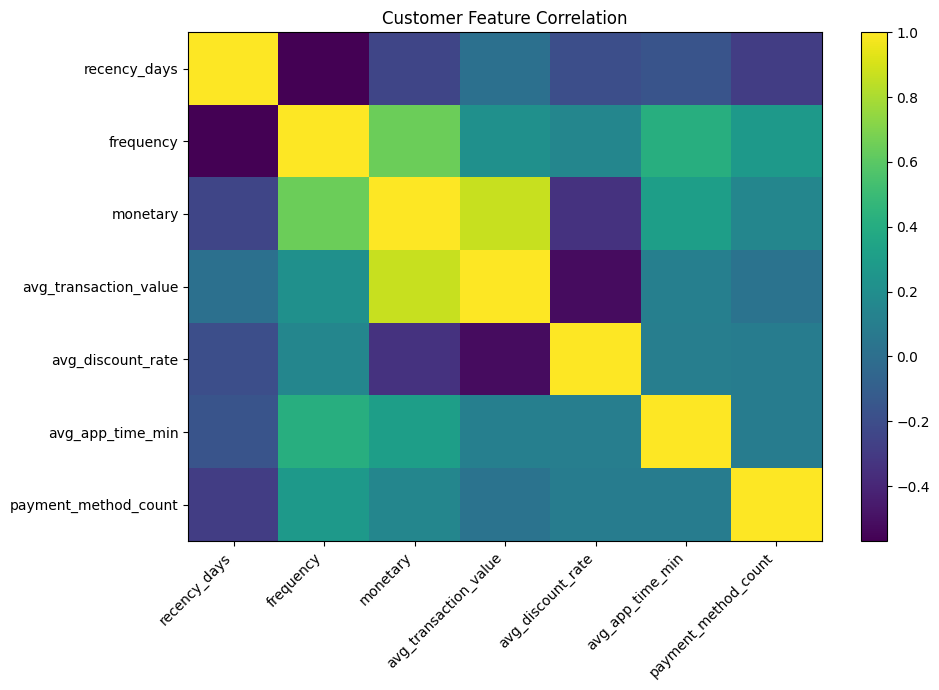

In [29]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.title("Customer Feature Correlation")

plt.tight_layout()
plt.show()

In [30]:
segmentation_features = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_transaction_value",
    "avg_discount_rate",
    "avg_app_time_min"
]

In [31]:
# ==========================================
# SAVE CORRELATION RESULTS
# ==========================================

corr_path = f"{project_dir}/results/customer_feature_correlation.csv"

corr.to_csv(corr_path)

print("✅ Correlation matrix saved:")
print(corr_path)

✅ Correlation matrix saved:
/content/drive/MyDrive/AOROA_Labs_Assignment/results/customer_feature_correlation.csv


In [32]:
# ==========================================
# STEP 4 — FEATURE TRANSFORMATION
# ==========================================

customer_model = customer_features.copy()

# Right-skewed features
customer_model["recency_log"] = np.log1p(
    customer_model["recency_days"]
)

customer_model["monetary_log"] = np.log1p(
    customer_model["monetary"]
)

# Final candidate features
model_features = [
    "recency_log",
    "frequency",
    "monetary_log",
    "avg_transaction_value",
    "avg_discount_rate",
    "avg_app_time_min"
]

print("=== MODEL FEATURES ===")
print(model_features)

display(
    customer_model[model_features].describe().T
)

=== MODEL FEATURES ===
['recency_log', 'frequency', 'monetary_log', 'avg_transaction_value', 'avg_discount_rate', 'avg_app_time_min']


,count,mean,std,min,25%,50%,75%,max
recency_log,800.0,1.783090,1.454490,0.000000,0.693147,1.609438,2.397895,6.070738
frequency,800.0,90.716250,22.792271,23.000000,82.000000,91.000000,100.000000,159.000000
monetary_log,800.0,15.276646,0.512829,13.571268,14.927449,15.239823,15.562921,16.998843
avg_transaction_value,800.0,53472.522993,22372.843110,15131.119048,37086.469038,49619.446237,64240.669269,188492.437500
avg_discount_rate,800.0,0.054055,0.062629,0.000000,0.010080,0.018750,0.125877,0.189444
avg_app_time_min,800.0,16.066627,6.487350,2.478723,11.321305,15.545455,20.285985,39.647887


In [33]:
# ==========================================
# TRANSFORMED SKEWNESS CHECK
# ==========================================

transformed_skewness = (
    customer_model[model_features]
    .skew()
    .sort_values(ascending=False)
)

display(
    transformed_skewness.to_frame("skewness")
)

,skewness
avg_transaction_value,1.333435
avg_discount_rate,0.941230
recency_log,0.916226
avg_app_time_min,0.404496
monetary_log,0.390045
frequency,-0.117233


In [34]:
# ==========================================
# STEP 5 — FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = customer_model[model_features].copy()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=model_features,
    index=customer_model.index
)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

display(X_scaled.describe().T)

Original shape: (800, 6)
Scaled shape: (800, 6)


,count,mean,std,min,25%,50%,75%,max
recency_log,800.0,1.554312e-17,1.000626,-1.226688,-0.749833,-0.119465,0.422959,2.949714
frequency,800.0,-9.436896e-17,1.000626,-2.972877,-0.382661,0.012457,0.407575,2.997791
monetary_log,800.0,1.549871e-15,1.000626,-3.327510,-0.681349,-0.071849,0.558576,3.360328
avg_transaction_value,800.0,5.995204e-17,1.000626,-1.714820,-0.732866,-0.172329,0.481605,6.038767
avg_discount_rate,800.0,3.552714e-17,1.000626,-0.863644,-0.702598,-0.564074,1.147497,2.163126
avg_app_time_min,800.0,5.662137e-16,1.000626,-2.095833,-0.731931,-0.080387,0.650805,3.637234


In [35]:
print("=== SCALED FEATURE CHECK ===")

print("\nMeans:")
display(X_scaled.mean().round(4))

print("\nStandard deviations:")
display(X_scaled.std().round(4))

=== SCALED FEATURE CHECK ===

Means:


,0
recency_log,0.0
frequency,-0.0
monetary_log,0.0
avg_transaction_value,0.0
avg_discount_rate,0.0
avg_app_time_min,0.0



Standard deviations:


,0
recency_log,1.0006
frequency,1.0006
monetary_log,1.0006
avg_transaction_value,1.0006
avg_discount_rate,1.0006
avg_app_time_min,1.0006


In [36]:
# ==========================================
# STEP 6 — K-MEANS EXPERIMENTS
# ==========================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)

    results.append({
        "k": k,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies,
        "inertia": kmeans.inertia_
    })

clustering_results = pd.DataFrame(results)

display(clustering_results.round(4))

,k,silhouette,calinski_harabasz,davies_bouldin,inertia
0,2,0.2961,287.9415,1.2586,3527.2619
1,3,0.3179,358.2360,1.1716,2527.6980
2,4,0.3566,415.1545,1.0360,1871.5984
3,5,0.2954,384.0808,1.2067,1636.8386
4,6,0.2658,350.7623,1.3050,1495.8722
5,7,0.2449,323.3384,1.3448,1392.7398
6,8,0.2424,305.0525,1.3251,1298.6411


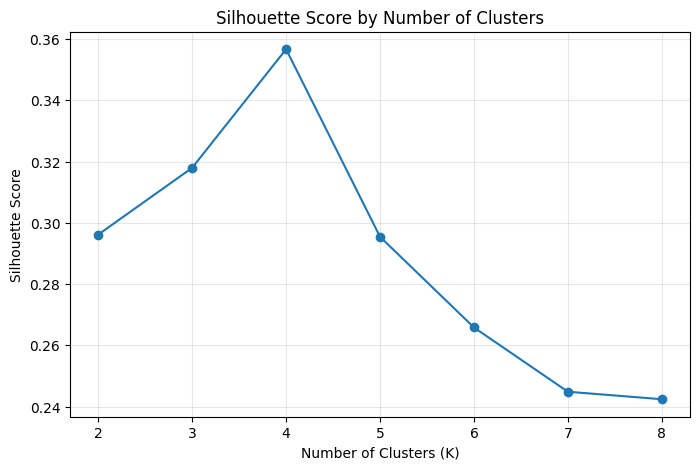

In [37]:
# ==========================================
# STEP 7 — CLUSTERING METRICS VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# Silhouette
plt.figure(figsize=(8, 5))
plt.plot(
    clustering_results["k"],
    clustering_results["silhouette"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)
plt.show()

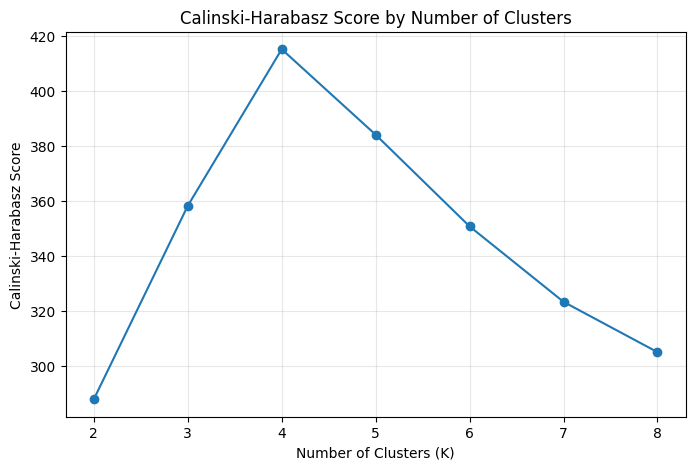

In [38]:
# Calinski-Harabasz

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_results["k"],
    clustering_results["calinski_harabasz"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)
plt.show()

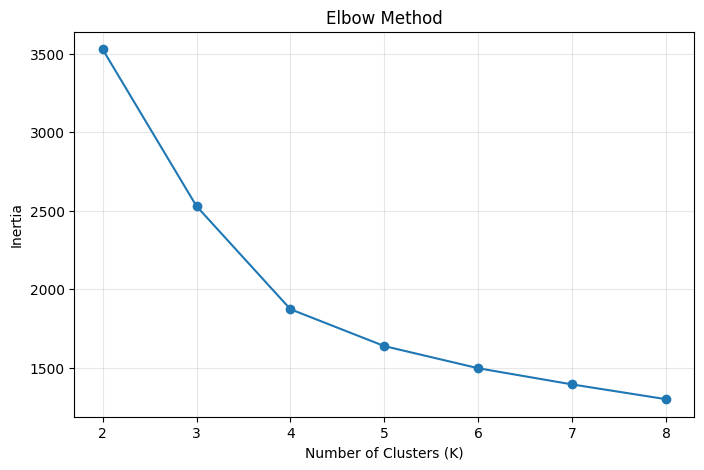

In [39]:
# Elbow / Inertia

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_results["k"],
    clustering_results["inertia"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# ==========================================
# STEP 8 — CLUSTER STABILITY TEST
# ==========================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seeds = [0, 7, 21, 42, 100, 2026]

stability_results = []

for seed in seeds:

    kmeans = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    stability_results.append({
        "random_state": seed,
        "silhouette": score,
        "inertia": kmeans.inertia_
    })

stability_results = pd.DataFrame(stability_results)

display(stability_results.round(4))

,random_state,silhouette,inertia
0,0,0.3566,1871.5984
1,7,0.3566,1871.5984
2,21,0.3566,1871.5984
3,42,0.3566,1871.5984
4,100,0.3564,1871.6018
5,2026,0.3564,1871.6018


In [41]:
# ==========================================
# STEP 9 — FINAL K=4 CLUSTERING
# ==========================================

from sklearn.cluster import KMeans

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

customer_model["cluster"] = final_kmeans.fit_predict(X_scaled)

print("=== CLUSTER COUNTS ===")
display(
    customer_model["cluster"]
    .value_counts()
    .sort_index()
)

=== CLUSTER COUNTS ===


,count
cluster,
0,360
1,238
2,94
3,108


In [42]:
# ==========================================
# CLUSTER PROFILE
# ==========================================

profile_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_transaction_value",
    "avg_discount_rate",
    "avg_app_time_min"
]

cluster_profile = (
    customer_model
    .groupby("cluster")[profile_cols]
    .agg(["mean", "median"])
)

display(cluster_profile.round(2))

recency_days        frequency            monetary              \
                mean median      mean median         mean      median   
cluster                                                                 
0               5.74    4.0     87.48   88.0   4927830.58   4734885.5   
1               4.52    3.0     97.12   97.0   3457862.90   3279101.5   
2               2.99    2.0    130.55  132.5  11427364.63  10584274.5   
3             134.96  117.0     52.70   51.5   2771244.82   2629645.5   

        avg_transaction_value           avg_discount_rate         \
                         mean    median              mean median   
cluster                                                            
0                    56516.00  54623.77              0.02   0.01   
1                    35542.85  33677.94              0.15   0.15   
2                    87648.19  83347.90              0.01   0.01   
3                    53093.80  50438.82              0.01   0.01   

        avg_app_time_min         
                    mean median  
cluster                          
0                  14.05  14.09  
1                  17.35  17.74  
2                  24.27  23.79  
3                  12.82  12.64

In [43]:
# ==========================================
# STEP 10 — CLUSTER SIZE
# ==========================================

cluster_size = (
    customer_model["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

cluster_size["percentage"] = (
    cluster_size["customer_count"]
    / len(customer_model)
    * 100
)

display(cluster_size.round(2))

,customer_count,percentage
cluster,,
0,360,45.00
1,238,29.75
2,94,11.75
3,108,13.50


In [44]:
# ==========================================
# STEP 10 — CLUSTER SIZE ANALYSIS
# ==========================================

cluster_size = (
    customer_model["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

cluster_size["percentage"] = (
    cluster_size["customer_count"]
    / len(customer_model)
    * 100
)

display(cluster_size.round(2))

,customer_count,percentage
cluster,,
0,360,45.00
1,238,29.75
2,94,11.75
3,108,13.50


In [45]:
# ==========================================
# COMBINED CLUSTER PROFILE
# ==========================================

cluster_summary = (
    customer_model
    .groupby("cluster")
    .agg(
        customers=("user_id", "count"),
        recency_days=("recency_days", "mean"),
        frequency=("frequency", "mean"),
        monetary=("monetary", "mean"),
        avg_transaction_value=("avg_transaction_value", "mean"),
        avg_discount_rate=("avg_discount_rate", "mean"),
        avg_app_time_min=("avg_app_time_min", "mean")
    )
)

cluster_summary["percentage"] = (
    cluster_summary["customers"]
    / len(customer_model)
    * 100
)

display(cluster_summary.round(2))

,customers,recency_days,frequency,monetary,avg_transaction_value,avg_discount_rate,avg_app_time_min,percentage
cluster,,,,,,,,
0,360,5.74,87.48,4927830.58,56516.00,0.02,14.05,45.00
1,238,4.52,97.12,3457862.90,35542.85,0.15,17.35,29.75
2,94,2.99,130.55,11427364.63,87648.19,0.01,24.27,11.75
3,108,134.96,52.70,2771244.82,53093.80,0.01,12.82,13.50


In [46]:
# ==========================================
# STEP 11 — PCA 2D VISUALIZATION
# ==========================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

customer_model["PCA1"] = X_pca[:, 0]
customer_model["PCA2"] = X_pca[:, 1]

explained_variance = pca.explained_variance_ratio_

print("PCA1 explained variance:", round(explained_variance[0], 4))
print("PCA2 explained variance:", round(explained_variance[1], 4))
print("Total explained variance:", round(explained_variance.sum(), 4))

PCA1 explained variance: 0.4314
PCA2 explained variance: 0.2912
Total explained variance: 0.7226


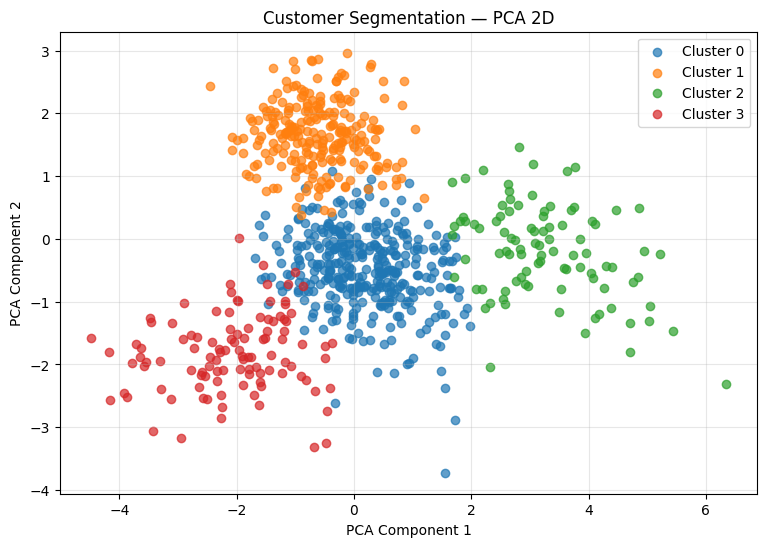

In [47]:
# ==========================================
# PCA CLUSTER PLOT
# ==========================================

plt.figure(figsize=(9, 6))

for cluster in sorted(customer_model["cluster"].unique()):

    subset = customer_model[
        customer_model["cluster"] == cluster
    ]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation — PCA 2D")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [48]:
# ==========================================
# STEP 12 — REVENUE CONTRIBUTION BY SEGMENT
# ==========================================

revenue_contribution = (
    customer_model
    .groupby("cluster")
    .agg(
        customers=("user_id", "count"),
        total_monetary=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median")
    )
)

# Customer share
revenue_contribution["customer_share_pct"] = (
    revenue_contribution["customers"]
    / len(customer_model)
    * 100
)

# Revenue share
total_revenue = revenue_contribution["total_monetary"].sum()

revenue_contribution["revenue_share_pct"] = (
    revenue_contribution["total_monetary"]
    / total_revenue
    * 100
)

display(
    revenue_contribution.round(2)
)

,customers,total_monetary,avg_monetary,median_monetary,customer_share_pct,revenue_share_pct
cluster,,,,,,
0,360,1774019007,4927830.58,4734885.5,45.00,44.68
1,238,822971370,3457862.90,3279101.5,29.75,20.73
2,94,1074172275,11427364.63,10584274.5,11.75,27.05
3,108,299294441,2771244.82,2629645.5,13.50,7.54


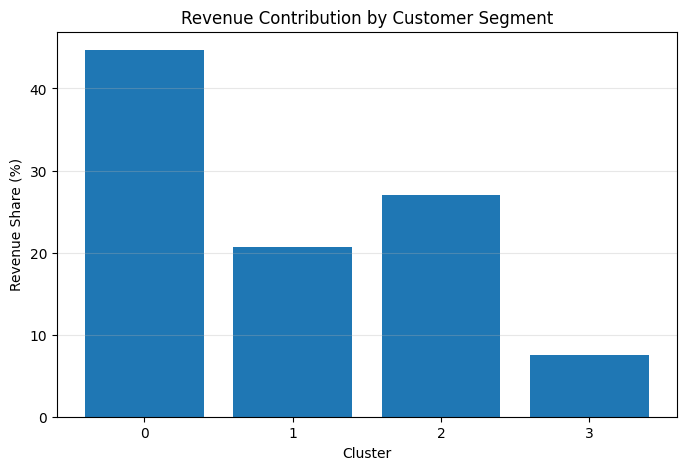

In [49]:
# ==========================================
# REVENUE SHARE VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_contribution.index.astype(str),
    revenue_contribution["revenue_share_pct"]
)

plt.xlabel("Cluster")
plt.ylabel("Revenue Share (%)")
plt.title("Revenue Contribution by Customer Segment")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [50]:
# ==========================================
# STEP 13 — SAVE DAY 2 RESULTS
# ==========================================

import os

# Create output directories
results_dir = f"{project_dir}/results"
reports_dir = f"{project_dir}/reports"
figures_dir = f"{project_dir}/figures"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)


# ------------------------------------------
# 1. Clustering experiment results
# ------------------------------------------

clustering_results.to_csv(
    f"{results_dir}/clustering_results_k2_k8.csv",
    index=False
)


# ------------------------------------------
# 2. Cluster profile
# ------------------------------------------

cluster_profile.to_csv(
    f"{results_dir}/cluster_profile.csv"
)


# ------------------------------------------
# 3. Cluster size
# ------------------------------------------

cluster_size.to_csv(
    f"{results_dir}/cluster_size.csv"
)


# ------------------------------------------
# 4. Revenue contribution
# ------------------------------------------

revenue_contribution.to_csv(
    f"{results_dir}/segment_revenue_contribution.csv"
)


# ------------------------------------------
# 5. Customer-level segmentation
# ------------------------------------------

customer_model.to_csv(
    f"{results_dir}/customer_segments.csv",
    index=False
)


# ------------------------------------------
# 6. Correlation matrix
# ------------------------------------------

corr.to_csv(
    f"{results_dir}/customer_feature_correlation.csv"
)


# ------------------------------------------
# 7. Stability results
# ------------------------------------------

stability_results.to_csv(
    f"{results_dir}/cluster_stability.csv",
    index=False
)


print("==========================================")
print("DAY 2 RESULTS SAVED SUCCESSFULLY")
print("==========================================")

for file in sorted(os.listdir(results_dir)):
    print("📄", file)

DAY 2 RESULTS SAVED SUCCESSFULLY
📄 baseline_validation_results.csv
📄 baseline_weekday_means.csv
📄 cluster_profile.csv
📄 cluster_size.csv
📄 cluster_stability.csv
📄 clustering_results_k2_k8.csv
📄 customer_feature_correlation.csv
📄 customer_features_raw.csv
📄 customer_segments.csv
📄 daily_sales.csv
📄 data_audit.csv
📄 eda_statistics.csv
📄 missing_values.csv
📄 segment_revenue_contribution.csv
📄 weekday_eda.csv


In [51]:
# ==========================================
# STEP 14 — BUSINESS SEGMENT PROFILE
# ==========================================

segment_names = {
    0: "Regular Valuable",
    1: "Discount-Driven",
    2: "High-Value Loyal",
    3: "At-Risk / Dormant"
}

business_actions = {
    0: "Retention, cross-sell, loyalty engagement",
    1: "Targeted promotions and discount optimization",
    2: "VIP retention, premium offers, priority protection",
    3: "Win-back campaigns and reactivation"
}

priorities = {
    0: "High",
    1: "Medium",
    2: "Critical",
    3: "High"
}

segment_business_profile = cluster_summary.copy()

segment_business_profile["segment_name"] = (
    segment_business_profile.index.map(segment_names)
)

segment_business_profile["recommended_action"] = (
    segment_business_profile.index.map(business_actions)
)

segment_business_profile["priority"] = (
    segment_business_profile.index.map(priorities)
)

# Reorder columns
segment_business_profile = segment_business_profile[
    [
        "segment_name",
        "customers",
        "percentage",
        "recency_days",
        "frequency",
        "monetary",
        "avg_transaction_value",
        "avg_discount_rate",
        "avg_app_time_min",
        "recommended_action",
        "priority"
    ]
]

display(segment_business_profile.round(2))

,segment_name,customers,percentage,recency_days,frequency,monetary,avg_transaction_value,avg_discount_rate,avg_app_time_min,recommended_action,priority
cluster,,,,,,,,,,,
0,Regular Valuable,360,45.00,5.74,87.48,4927830.58,56516.00,0.02,14.05,"Retention, cross-sell, loyalty engagement",High
1,Discount-Driven,238,29.75,4.52,97.12,3457862.90,35542.85,0.15,17.35,Targeted promotions and discount optimization,Medium
2,High-Value Loyal,94,11.75,2.99,130.55,11427364.63,87648.19,0.01,24.27,"VIP retention, premium offers, priority protec...",Critical
3,At-Risk / Dormant,108,13.50,134.96,52.70,2771244.82,53093.80,0.01,12.82,Win-back campaigns and reactivation,High


In [52]:
segment_business_profile.to_csv(
    f"{results_dir}/segment_business_profile.csv",
    index=True
)

print("✅ Business segment profile saved.")

✅ Business segment profile saved.


In [53]:
# ==========================================
# STEP 15 — DAY 2 REPORT
# ==========================================

day2_report = """
# AOROA Labs — Day 2 Customer Segmentation

## Dataset

- Customers analyzed: 800
- Clustering method: K-Means
- Candidate K values: 2–8
- Final candidate: K=4
- Scaling: StandardScaler
- Transformation: log1p applied to recency and monetary

## Feature Selection

Primary clustering features:

- recency_days
- frequency
- monetary
- avg_transaction_value
- avg_discount_rate
- avg_app_time_min

payment_method_count was excluded from primary clustering because of very low variance and limited discriminative power.

## Model Selection

K=4 achieved:

- Silhouette Score: 0.3566
- Calinski-Harabasz Score: 415.15
- Davies-Bouldin Score: 1.0360

K=4 was also supported by the elbow analysis.

## Stability

The K=4 solution remained highly stable across multiple random seeds.

Silhouette scores remained approximately 0.3564–0.3566.

## Customer Segments

### Cluster 0 — Regular Valuable
- 360 customers
- 45.00% of customers
- 44.68% of monetary value

Recommended action:
Retention, cross-sell and loyalty engagement.

### Cluster 1 — Discount-Driven
- 238 customers
- 29.75% of customers
- 20.73% of monetary value

Key characteristic:
High discount usage with comparatively lower monetary value.

Recommended action:
Targeted promotions and discount optimization.

### Cluster 2 — High-Value Loyal
- 94 customers
- 11.75% of customers
- 27.05% of monetary value

Key characteristic:
Highest frequency, highest monetary value and highest app engagement.

Recommended action:
VIP retention and premium customer protection.

### Cluster 3 — At-Risk / Dormant
- 108 customers
- 13.50% of customers
- 7.54% of monetary value

Key characteristic:
Very high recency, approximately 135 days since last purchase.

Recommended action:
Win-back and reactivation campaigns.

## PCA Validation

The first two PCA components explain 72.26% of total variance:

- PCA1: 43.14%
- PCA2: 29.12%

The 2D projection shows meaningful separation between the four customer segments.

## Business Conclusion

The segmentation identifies four commercially meaningful customer groups with distinct behavioral and monetary characteristics.

The High-Value Loyal segment represents only 11.75% of customers but contributes approximately 27.05% of total monetary value, indicating strong strategic importance.

The At-Risk / Dormant segment represents 13.50% of customers and approximately 7.54% of monetary value, providing a clear target for reactivation initiatives.
"""

report_path = f"{reports_dir}/Day2_Segmentation_Findings.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(day2_report)

print("✅ Day 2 report saved:")
print(report_path)

✅ Day 2 report saved:
/content/drive/MyDrive/AOROA_Labs_Assignment/reports/Day2_Segmentation_Findings.md


In [54]:
import os

base_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"

for folder in ["data", "results", "figures", "reports", "src"]:

    path = os.path.join(base_dir, folder)

    print(f"\n📁 {folder}/")

    if os.path.exists(path):
        for file in sorted(os.listdir(path)):
            print("   📄", file)
    else:
        print("   ⚠️ Folder not found")


📁 data/

📁 results/
   📄 baseline_validation_results.csv
   📄 baseline_weekday_means.csv
   📄 cluster_profile.csv
   📄 cluster_size.csv
   📄 cluster_stability.csv
   📄 clustering_results_k2_k8.csv
   📄 customer_feature_correlation.csv
   📄 customer_features_raw.csv
   📄 customer_segments.csv
   📄 daily_sales.csv
   📄 data_audit.csv
   📄 eda_statistics.csv
   📄 missing_values.csv
   📄 segment_business_profile.csv
   📄 segment_revenue_contribution.csv
   📄 weekday_eda.csv

📁 figures/

📁 reports/
   📄 Day2_Segmentation_Findings.md
   📄 EDA_Findings_Assumptions.md

📁 src/


DAY-3 @@@@@@@@@@@@@@@@@@@@@

In [55]:
# ==========================================
# DAY 3 — STEP 1
# 56-DAY WEEKDAY BASELINE
# ==========================================

import pandas as pd
import numpy as np

# Load daily sales
daily_sales = pd.read_csv(
    f"{project_dir}/results/daily_sales.csv",
    parse_dates=["date"]
)

daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

print("Rows:", len(daily_sales))
print("Date range:", daily_sales["date"].min(), "→", daily_sales["date"].max())

# Last 56 historical days
baseline_window = daily_sales.tail(56).copy()

print("\nBaseline window:")
print(baseline_window["date"].min(), "→", baseline_window["date"].max())

# Weekday mapping
baseline_window["weekday"] = baseline_window["date"].dt.day_name()

# Weekday means
weekday_baseline = (
    baseline_window
    .groupby("weekday")["total_sales"]
    .mean()
)

print("\n=== 56-DAY WEEKDAY BASELINE ===")
print(weekday_baseline.round(2))

Rows: 703
Date range: 2022-07-01 00:00:00 → 2024-06-02 00:00:00

Baseline window:
2024-04-08 00:00:00 → 2024-06-02 00:00:00

=== 56-DAY WEEKDAY BASELINE ===
weekday
Friday       5806245.88
Monday       5454541.12
Saturday     8006123.38
Sunday       7344284.62
Thursday     5832691.88
Tuesday      5949559.62
Wednesday    5876613.38
Name: total_sales, dtype: float64


In [56]:
# ==========================================
# 7-DAY BASELINE FORECAST
# ==========================================

last_date = daily_sales["date"].max()

forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

baseline_forecast = pd.DataFrame({
    "date": forecast_dates
})

baseline_forecast["weekday"] = (
    baseline_forecast["date"].dt.day_name()
)

baseline_forecast["forecast"] = (
    baseline_forecast["weekday"]
    .map(weekday_baseline)
)

display(baseline_forecast)

,date,weekday,forecast
0,2024-06-03,Monday,5454541.125
1,2024-06-04,Tuesday,5949559.625
2,2024-06-05,Wednesday,5876613.375
3,2024-06-06,Thursday,5832691.875
4,2024-06-07,Friday,5806245.875
5,2024-06-08,Saturday,8006123.375
6,2024-06-09,Sunday,7344284.625


In [57]:
# ==========================================
# DAY 3 — STEP 2
# ROLLING BACKTEST WINDOWS
# ==========================================

daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

# Forecast horizon
HORIZON = 7

# Number of historical validation windows
N_WINDOWS = 8

# Create rolling cutoff dates
validation_windows = []

for i in range(N_WINDOWS, 0, -1):

    cutoff_idx = len(daily_sales) - HORIZON * i

    cutoff_date = daily_sales.loc[cutoff_idx, "date"]

    forecast_start = cutoff_date + pd.Timedelta(days=1)
    forecast_end = forecast_start + pd.Timedelta(days=HORIZON - 1)

    validation_windows.append({
        "cutoff_date": cutoff_date,
        "forecast_start": forecast_start,
        "forecast_end": forecast_end
    })

validation_windows = pd.DataFrame(validation_windows)

print("=== ROLLING VALIDATION WINDOWS ===")
display(validation_windows)

=== ROLLING VALIDATION WINDOWS ===


,cutoff_date,forecast_start,forecast_end
0,2024-04-08,2024-04-09,2024-04-15
1,2024-04-15,2024-04-16,2024-04-22
2,2024-04-22,2024-04-23,2024-04-29
3,2024-04-29,2024-04-30,2024-05-06
4,2024-05-06,2024-05-07,2024-05-13
5,2024-05-13,2024-05-14,2024-05-20
6,2024-05-20,2024-05-21,2024-05-27
7,2024-05-27,2024-05-28,2024-06-03


In [58]:
# ==========================================
# LEAKAGE CHECK
# ==========================================

print("=== VALIDATION LEAKAGE CHECK ===")

for _, row in validation_windows.iterrows():

    cutoff = row["cutoff_date"]
    forecast_start = row["forecast_start"]

    assert forecast_start > cutoff

print("✅ No future data is used before forecast cutoff.")

=== VALIDATION LEAKAGE CHECK ===
✅ No future data is used before forecast cutoff.


In [59]:
# ==========================================
# STEP 2C — KEEP ONLY COMPLETE WINDOWS
# ==========================================

complete_windows = validation_windows[
    validation_windows["forecast_end"] <= daily_sales["date"].max()
].copy()

print("=== COMPLETE VALIDATION WINDOWS ===")
display(complete_windows)

print(
    "\nComplete windows:",
    len(complete_windows)
)

print(
    "Total validation days:",
    len(complete_windows) * HORIZON
)

=== COMPLETE VALIDATION WINDOWS ===


,cutoff_date,forecast_start,forecast_end
0,2024-04-08,2024-04-09,2024-04-15
1,2024-04-15,2024-04-16,2024-04-22
2,2024-04-22,2024-04-23,2024-04-29
3,2024-04-29,2024-04-30,2024-05-06
4,2024-05-06,2024-05-07,2024-05-13
5,2024-05-13,2024-05-14,2024-05-20
6,2024-05-20,2024-05-21,2024-05-27



Complete windows: 7
Total validation days: 49


In [60]:
# ==========================================
# DAY 3 — STEP 3
# TREND + WEEKDAY + FOURIER MODEL
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def create_fourier_features(dates, period=7, order=3):
    """
    Create weekly Fourier seasonality features.
    """
    dates = pd.to_datetime(dates)

    # Continuous time index
    t = (dates - daily_sales["date"].min()).dt.days.values

    features = {}

    for k in range(1, order + 1):
        features[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        features[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return pd.DataFrame(features, index=dates.index)


def build_trend_weekday_fourier_model(train_df, forecast_dates, fourier_order=3):

    train = train_df.copy()
    forecast_dates = pd.Series(pd.to_datetime(forecast_dates))

    # Time index
    origin = train["date"].min()

    train["t"] = (
        train["date"] - origin
    ).dt.days

    forecast_t = (
        forecast_dates - origin
    ).dt.days

    # Weekday
    train["weekday"] = train["date"].dt.dayofweek
    forecast_weekday = forecast_dates.dt.dayofweek

    # Fourier
    train_fourier = create_fourier_features(
        train["date"],
        period=7,
        order=fourier_order
    )

    forecast_fourier = create_fourier_features(
        forecast_dates,
        period=7,
        order=fourier_order
    )

    # Build training features
    X_train = pd.DataFrame({
        "t": train["t"].values,
    })

    # One-hot weekday
    weekday_train = pd.get_dummies(
        train["weekday"],
        prefix="weekday"
    )

    weekday_forecast = pd.get_dummies(
        forecast_weekday,
        prefix="weekday"
    )

    # Ensure same weekday columns
    weekday_forecast = weekday_forecast.reindex(
        columns=weekday_train.columns,
        fill_value=0
    )

    X_train = pd.concat(
        [
            X_train.reset_index(drop=True),
            weekday_train.reset_index(drop=True),
            train_fourier.reset_index(drop=True)
        ],
        axis=1
    )

    X_forecast = pd.DataFrame({
        "t": forecast_t.values
    })

    X_forecast = pd.concat(
        [
            X_forecast.reset_index(drop=True),
            weekday_forecast.reset_index(drop=True),
            forecast_fourier.reset_index(drop=True)
        ],
        axis=1
    )

    # Fit model
    model = LinearRegression()

    model.fit(
        X_train,
        train["total_sales"]
    )

    # Forecast
    predictions = model.predict(X_forecast)

    return predictions, model


print("✅ Trend + Weekday + Fourier functions created.")

✅ Trend + Weekday + Fourier functions created.


In [61]:
# ==========================================
# DAY 3 — STEP 3B
# FOURIER MODEL ROLLING BACKTEST
# ==========================================

fourier_backtest_results = []

for _, window in complete_windows.iterrows():

    cutoff_date = window["cutoff_date"]
    forecast_start = window["forecast_start"]
    forecast_end = window["forecast_end"]

    # --------------------------------------
    # TRAIN: ONLY DATA AVAILABLE AT CUTOFF
    # --------------------------------------
    train_df = daily_sales[
        daily_sales["date"] <= cutoff_date
    ].copy()

    # --------------------------------------
    # ACTUAL VALIDATION DATA
    # --------------------------------------
    actual_df = daily_sales[
        (daily_sales["date"] >= forecast_start) &
        (daily_sales["date"] <= forecast_end)
    ].copy()

    # --------------------------------------
    # FORECAST
    # --------------------------------------
    forecast_dates = actual_df["date"]

    predictions, model = build_trend_weekday_fourier_model(
        train_df,
        forecast_dates,
        fourier_order=3
    )

    # --------------------------------------
    # SAVE DAILY RESULTS
    # --------------------------------------
    for date, actual, prediction in zip(
        actual_df["date"],
        actual_df["total_sales"],
        predictions
    ):

        fourier_backtest_results.append({
            "cutoff_date": cutoff_date,
            "date": date,
            "actual": actual,
            "forecast": prediction
        })


fourier_backtest_results = pd.DataFrame(
    fourier_backtest_results
)

# ------------------------------------------
# METRICS
# ------------------------------------------

fourier_backtest_results["error"] = (
    fourier_backtest_results["actual"]
    - fourier_backtest_results["forecast"]
)

fourier_backtest_results["absolute_error"] = (
    fourier_backtest_results["error"].abs()
)

fourier_backtest_results["squared_error"] = (
    fourier_backtest_results["error"] ** 2
)

# MAPE
fourier_backtest_results["absolute_percentage_error"] = (
    fourier_backtest_results["absolute_error"]
    / fourier_backtest_results["actual"].abs()
) * 100


mae_fourier = (
    fourier_backtest_results["absolute_error"].mean()
)

rmse_fourier = np.sqrt(
    fourier_backtest_results["squared_error"].mean()
)

mape_fourier = (
    fourier_backtest_results["absolute_percentage_error"].mean()
)


print("==========================================")
print("FOURIER MODEL BACKTEST RESULTS")
print("==========================================")

print(f"Validation days : {len(fourier_backtest_results)}")
print(f"MAE              : {mae_fourier:,.2f}")
print(f"RMSE             : {rmse_fourier:,.2f}")
print(f"MAPE             : {mape_fourier:.2f}%")

FOURIER MODEL BACKTEST RESULTS
Validation days : 49
MAE              : 551,328.20
RMSE             : 702,445.75
MAPE             : 8.53%


In [62]:
# ==========================================
# DAY 3 — STEP 3C
# 56-DAY WEEKDAY BASELINE BACKTEST
# ==========================================

baseline_backtest_results = []

for _, window in complete_windows.iterrows():

    cutoff_date = window["cutoff_date"]
    forecast_start = window["forecast_start"]
    forecast_end = window["forecast_end"]

    # --------------------------------------
    # TRAIN DATA — ONLY BEFORE FORECAST
    # --------------------------------------
    train_df = daily_sales[
        daily_sales["date"] <= cutoff_date
    ].copy()

    # Last 56 days available at cutoff
    baseline_window = train_df.tail(56).copy()

    # Weekday averages
    weekday_means = (
        baseline_window
        .groupby(
            baseline_window["date"].dt.day_name()
        )["total_sales"]
        .mean()
    )

    # --------------------------------------
    # ACTUAL VALIDATION DATA
    # --------------------------------------
    actual_df = daily_sales[
        (daily_sales["date"] >= forecast_start) &
        (daily_sales["date"] <= forecast_end)
    ].copy()

    # --------------------------------------
    # FORECAST
    # --------------------------------------
    actual_df = actual_df.copy()

    actual_df["weekday"] = (
        actual_df["date"].dt.day_name()
    )

    actual_df["forecast"] = (
        actual_df["weekday"]
        .map(weekday_means)
    )

    # --------------------------------------
    # SAVE
    # --------------------------------------
    for _, row in actual_df.iterrows():

        baseline_backtest_results.append({
            "cutoff_date": cutoff_date,
            "date": row["date"],
            "actual": row["total_sales"],
            "forecast": row["forecast"]
        })


baseline_backtest_results = pd.DataFrame(
    baseline_backtest_results
)

# ------------------------------------------
# METRICS
# ------------------------------------------

baseline_backtest_results["error"] = (
    baseline_backtest_results["actual"]
    - baseline_backtest_results["forecast"]
)

baseline_backtest_results["absolute_error"] = (
    baseline_backtest_results["error"].abs()
)

baseline_backtest_results["squared_error"] = (
    baseline_backtest_results["error"] ** 2
)

baseline_backtest_results["absolute_percentage_error"] = (
    baseline_backtest_results["absolute_error"]
    / baseline_backtest_results["actual"].abs()
) * 100


mae_baseline = (
    baseline_backtest_results["absolute_error"].mean()
)

rmse_baseline = np.sqrt(
    baseline_backtest_results["squared_error"].mean()
)

mape_baseline = (
    baseline_backtest_results["absolute_percentage_error"].mean()
)


print("==========================================")
print("56-DAY WEEKDAY BASELINE BACKTEST")
print("==========================================")

print(f"Validation days : {len(baseline_backtest_results)}")
print(f"MAE              : {mae_baseline:,.2f}")
print(f"RMSE             : {rmse_baseline:,.2f}")
print(f"MAPE             : {mape_baseline:.2f}%")

56-DAY WEEKDAY BASELINE BACKTEST
Validation days : 49
MAE              : 564,069.73
RMSE             : 707,357.77
MAPE             : 8.96%


In [63]:
# ==========================================
# DAY 3 — STEP 3C
# 56-DAY WEEKDAY BASELINE BACKTEST
# ==========================================

baseline_backtest_results = []

for _, window in complete_windows.iterrows():

    cutoff_date = window["cutoff_date"]
    forecast_start = window["forecast_start"]
    forecast_end = window["forecast_end"]

    # --------------------------------------
    # TRAIN DATA — ONLY BEFORE FORECAST
    # --------------------------------------
    train_df = daily_sales[
        daily_sales["date"] <= cutoff_date
    ].copy()

    # Last 56 days available at cutoff
    baseline_window = train_df.tail(56).copy()

    # Weekday averages
    weekday_means = (
        baseline_window
        .groupby(
            baseline_window["date"].dt.day_name()
        )["total_sales"]
        .mean()
    )

    # --------------------------------------
    # ACTUAL VALIDATION DATA
    # --------------------------------------
    actual_df = daily_sales[
        (daily_sales["date"] >= forecast_start) &
        (daily_sales["date"] <= forecast_end)
    ].copy()

    # --------------------------------------
    # FORECAST
    # --------------------------------------
    actual_df = actual_df.copy()

    actual_df["weekday"] = (
        actual_df["date"].dt.day_name()
    )

    actual_df["forecast"] = (
        actual_df["weekday"]
        .map(weekday_means)
    )

    # --------------------------------------
    # SAVE
    # --------------------------------------
    for _, row in actual_df.iterrows():

        baseline_backtest_results.append({
            "cutoff_date": cutoff_date,
            "date": row["date"],
            "actual": row["total_sales"],
            "forecast": row["forecast"]
        })


baseline_backtest_results = pd.DataFrame(
    baseline_backtest_results
)

# ------------------------------------------
# METRICS
# ------------------------------------------

baseline_backtest_results["error"] = (
    baseline_backtest_results["actual"]
    - baseline_backtest_results["forecast"]
)

baseline_backtest_results["absolute_error"] = (
    baseline_backtest_results["error"].abs()
)

baseline_backtest_results["squared_error"] = (
    baseline_backtest_results["error"] ** 2
)

baseline_backtest_results["absolute_percentage_error"] = (
    baseline_backtest_results["absolute_error"]
    / baseline_backtest_results["actual"].abs()
) * 100


mae_baseline = (
    baseline_backtest_results["absolute_error"].mean()
)

rmse_baseline = np.sqrt(
    baseline_backtest_results["squared_error"].mean()
)

mape_baseline = (
    baseline_backtest_results["absolute_percentage_error"].mean()
)


print("==========================================")
print("56-DAY WEEKDAY BASELINE BACKTEST")
print("==========================================")

print(f"Validation days : {len(baseline_backtest_results)}")
print(f"MAE              : {mae_baseline:,.2f}")
print(f"RMSE             : {rmse_baseline:,.2f}")
print(f"MAPE             : {mape_baseline:.2f}%")

56-DAY WEEKDAY BASELINE BACKTEST
Validation days : 49
MAE              : 564,069.73
RMSE             : 707,357.77
MAPE             : 8.96%


In [64]:
# ==========================================
# DAY 3 — STEP 4A
# LAG + ROLLING FEATURES
# ==========================================

def create_lag_features(df):
    data = df.copy()
    data = data.sort_values("date").reset_index(drop=True)

    # Calendar features
    data["weekday"] = data["date"].dt.dayofweek
    data["trend"] = np.arange(len(data))

    # Lag features
    data["lag_1"] = data["total_sales"].shift(1)
    data["lag_7"] = data["total_sales"].shift(7)
    data["lag_14"] = data["total_sales"].shift(14)

    # Rolling features
    # IMPORTANT: shift(1) prevents using today's actual sales
    data["rolling_mean_7"] = (
        data["total_sales"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    data["rolling_mean_14"] = (
        data["total_sales"]
        .shift(1)
        .rolling(14)
        .mean()
    )

    data["rolling_mean_28"] = (
        data["total_sales"]
        .shift(1)
        .rolling(28)
        .mean()
    )

    return data


lag_data = create_lag_features(daily_sales)

feature_cols = [
    "weekday",
    "trend",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

print("=== LAG + ROLLING FEATURES ===")
display(
    lag_data[
        ["date", "total_sales"] + feature_cols
    ].tail(10)
)

print("\nFeature columns:")
print(feature_cols)

=== LAG + ROLLING FEATURES ===


,date,total_sales,weekday,trend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_mean_28
693,2024-05-24,5603965,4,693,5775657.0,4939871.0,5746351.0,6.046169e+06,6.115820e+06,6.191273e+06
694,2024-05-25,8286227,5,694,5603965.0,7034970.0,9183453.0,6.141039e+06,6.105649e+06,6.158649e+06
695,2024-05-26,7042956,6,695,8286227.0,8093715.0,6945934.0,6.319790e+06,6.041562e+06,6.211767e+06
696,2024-05-27,6031171,0,696,7042956.0,5161361.0,5053304.0,6.169682e+06,6.048492e+06,6.189719e+06
697,2024-05-28,5745807,1,697,6031171.0,6069116.0,6324519.0,6.293940e+06,6.118340e+06,6.211918e+06
698,2024-05-29,5658009,2,698,5745807.0,5248491.0,5060674.0,6.247753e+06,6.077003e+06,6.212595e+06
699,2024-05-30,4751159,3,699,5658009.0,5775657.0,4984061.0,6.306256e+06,6.119670e+06,6.216998e+06
700,2024-05-31,6542376,4,700,4751159.0,5603965.0,4939871.0,6.159899e+06,6.103034e+06,6.148904e+06
701,2024-06-01,7473235,5,701,6542376.0,8286227.0,7034970.0,6.293958e+06,6.217499e+06,6.192002e+06
702,2024-06-02,7092541,6,702,7473235.0,7042956.0,8093715.0,6.177816e+06,6.248803e+06,6.195823e+06



Feature columns:
['weekday', 'trend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28']


In [65]:
# ==========================================
# DAY 3 — STEP 4B
# LAG + ROLLING MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor

lag_model_results = []

for _, window in complete_windows.iterrows():

    cutoff_date = window["cutoff_date"]
    forecast_start = window["forecast_start"]
    forecast_end = window["forecast_end"]

    # --------------------------------------
    # TRAIN DATA
    # --------------------------------------
    train = lag_data[
        lag_data["date"] <= cutoff_date
    ].copy()

    # Remove rows with unavailable lag features
    train = train.dropna(
        subset=feature_cols + ["total_sales"]
    )

    X_train = train[feature_cols]
    y_train = train["total_sales"]

    # --------------------------------------
    # MODEL
    # --------------------------------------
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # --------------------------------------
    # RECURSIVE 7-DAY FORECAST
    # --------------------------------------

    history = daily_sales[
        daily_sales["date"] <= cutoff_date
    ][["date", "total_sales"]].copy()

    predictions = []

    for step in range(7):

        forecast_date = (
            cutoff_date
            + pd.Timedelta(days=step + 1)
        )

        temp = history.copy()

        # Calendar
        weekday = forecast_date.dayofweek
        trend = len(temp)

        # Lag values
        lag_1 = temp["total_sales"].iloc[-1]
        lag_7 = temp["total_sales"].iloc[-7]
        lag_14 = temp["total_sales"].iloc[-14]

        # Rolling values
        rolling_mean_7 = (
            temp["total_sales"]
            .tail(7)
            .mean()
        )

        rolling_mean_14 = (
            temp["total_sales"]
            .tail(14)
            .mean()
        )

        rolling_mean_28 = (
            temp["total_sales"]
            .tail(28)
            .mean()
        )

        X_future = pd.DataFrame([{
            "weekday": weekday,
            "trend": trend,
            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_14": rolling_mean_14,
            "rolling_mean_28": rolling_mean_28
        }])

        prediction = model.predict(
            X_future[feature_cols]
        )[0]

        predictions.append(prediction)

        # Add prediction to history
        history = pd.concat(
            [
                history,
                pd.DataFrame({
                    "date": [forecast_date],
                    "total_sales": [prediction]
                })
            ],
            ignore_index=True
        )

    # --------------------------------------
    # ACTUAL VALUES
    # --------------------------------------

    actual_df = daily_sales[
        (daily_sales["date"] >= forecast_start) &
        (daily_sales["date"] <= forecast_end)
    ].copy()

    for date, actual, prediction in zip(
        actual_df["date"],
        actual_df["total_sales"],
        predictions
    ):

        lag_model_results.append({
            "cutoff_date": cutoff_date,
            "date": date,
            "actual": actual,
            "forecast": prediction
        })


lag_model_results = pd.DataFrame(
    lag_model_results
)

# ==========================================
# METRICS
# ==========================================

lag_model_results["error"] = (
    lag_model_results["actual"]
    - lag_model_results["forecast"]
)

lag_model_results["absolute_error"] = (
    lag_model_results["error"].abs()
)

lag_model_results["squared_error"] = (
    lag_model_results["error"] ** 2
)

lag_model_results["absolute_percentage_error"] = (
    lag_model_results["absolute_error"]
    / lag_model_results["actual"].abs()
) * 100


mae_lag = lag_model_results["absolute_error"].mean()

rmse_lag = np.sqrt(
    lag_model_results["squared_error"].mean()
)

mape_lag = (
    lag_model_results["absolute_percentage_error"].mean()
)


print("==========================================")
print("LAG + ROLLING MODEL BACKTEST")
print("==========================================")

print(f"Validation days : {len(lag_model_results)}")
print(f"MAE              : {mae_lag:,.2f}")
print(f"RMSE             : {rmse_lag:,.2f}")
print(f"MAPE             : {mape_lag:.2f}%")

LAG + ROLLING MODEL BACKTEST
Validation days : 49
MAE              : 562,520.32
RMSE             : 692,877.38
MAPE             : 8.86%


In [66]:
# ==========================================
# DAY 3 — STEP 5
# MODEL COMPARISON
# ==========================================

model_comparison = pd.DataFrame({
    "model": [
        "56-day Weekday Baseline",
        "Trend + Weekday + Fourier",
        "Lag + Rolling"
    ],
    "MAE": [
        mae_baseline,
        mae_fourier,
        mae_lag
    ],
    "RMSE": [
        rmse_baseline,
        rmse_fourier,
        rmse_lag
    ],
    "MAPE": [
        mape_baseline,
        mape_fourier,
        mape_lag
    ]
})

# Improvement relative to baseline
model_comparison["MAE_improvement_pct"] = (
    (mae_baseline - model_comparison["MAE"])
    / mae_baseline * 100
)

model_comparison["RMSE_improvement_pct"] = (
    (rmse_baseline - model_comparison["RMSE"])
    / rmse_baseline * 100
)

model_comparison["MAPE_improvement_pct"] = (
    (mape_baseline - model_comparison["MAPE"])
    / mape_baseline * 100
)

print("==========================================")
print("MODEL COMPARISON")
print("==========================================")

display(
    model_comparison.round(3)
)

MODEL COMPARISON


,model,MAE,RMSE,MAPE,MAE_improvement_pct,RMSE_improvement_pct,MAPE_improvement_pct
0,56-day Weekday Baseline,564069.73,707357.774,8.959,0.000,0.000,0.000
1,Trend + Weekday + Fourier,551328.20,702445.753,8.526,2.259,0.694,4.840
2,Lag + Rolling,562520.32,692877.380,8.862,0.275,2.047,1.086


In [67]:
# ==========================================
# DAY 3 — STEP 6
# ROBUSTNESS / STABILITY CHECK
# ==========================================

def calculate_window_metrics(df, model_name):

    rows = []

    for cutoff, group in df.groupby("cutoff_date"):

        actual = group["actual"].values
        forecast = group["forecast"].values

        mae = np.mean(np.abs(actual - forecast))
        rmse = np.sqrt(np.mean((actual - forecast) ** 2))
        mape = np.mean(
            np.abs((actual - forecast) / actual)
        ) * 100

        rows.append({
            "model": model_name,
            "cutoff_date": cutoff,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    return pd.DataFrame(rows)


# Calculate metrics for each validation window
baseline_window_metrics = calculate_window_metrics(
    baseline_backtest_results,
    "56-day Weekday Baseline"
)

fourier_window_metrics = calculate_window_metrics(
    fourier_backtest_results,
    "Trend + Weekday + Fourier"
)

lag_window_metrics = calculate_window_metrics(
    lag_model_results,
    "Lag + Rolling"
)


# Combine
window_metrics = pd.concat(
    [
        baseline_window_metrics,
        fourier_window_metrics,
        lag_window_metrics
    ],
    ignore_index=True
)

print("==========================================")
print("WINDOW-LEVEL ROBUSTNESS CHECK")
print("==========================================")

display(
    window_metrics.round(2)
)

WINDOW-LEVEL ROBUSTNESS CHECK


,model,cutoff_date,MAE,RMSE,MAPE
0,56-day Weekday Baseline,2024-04-08,882112.34,1060848.89,12.33
1,56-day Weekday Baseline,2024-04-15,273418.16,380122.76,4.37
2,56-day Weekday Baseline,2024-04-22,398758.18,566123.72,6.06
3,56-day Weekday Baseline,2024-04-29,606309.09,670689.49,10.12
4,56-day Weekday Baseline,2024-05-06,640091.52,729901.28,9.87
5,56-day Weekday Baseline,2024-05-13,728582.29,833547.74,13.07
6,56-day Weekday Baseline,2024-05-20,419216.54,484472.17,6.89
7,Trend + Weekday + Fourier,2024-04-08,917361.10,1186386.65,12.25
8,Trend + Weekday + Fourier,2024-04-15,336572.06,378269.45,5.16
9,Trend + Weekday + Fourier,2024-04-22,440183.90,496028.02,6.75


In [68]:
# ==========================================
# STABILITY SUMMARY
# ==========================================

stability_summary = (
    window_metrics
    .groupby("model")
    .agg(
        mean_mae=("MAE", "mean"),
        std_mae=("MAE", "std"),
        mean_rmse=("RMSE", "mean"),
        std_rmse=("RMSE", "std"),
        mean_mape=("MAPE", "mean"),
        std_mape=("MAPE", "std")
    )
    .reset_index()
)

print("==========================================")
print("STABILITY SUMMARY")
print("==========================================")

display(
    stability_summary.round(2)
)

STABILITY SUMMARY


,model,mean_mae,std_mae,mean_rmse,std_rmse,mean_mape,std_mape
0,56-day Weekday Baseline,564069.73,211568.61,675100.86,228092.41,8.96,3.27
1,Lag + Rolling,562520.32,180843.76,663496.48,215623.30,8.86,2.85
2,Trend + Weekday + Fourier,551328.20,209075.68,654019.98,276831.87,8.53,3.09


In [69]:
# ==========================================
# DAY 3 — STEP 7
# FINAL FORECAST
# ==========================================

final_train = daily_sales.copy()

final_forecast_dates = pd.date_range(
    start=final_train["date"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

final_predictions, final_model = (
    build_trend_weekday_fourier_model(
        final_train,
        final_forecast_dates,
        fourier_order=3
    )
)

submission_forecast = pd.DataFrame({
    "date": final_forecast_dates,
    "forecast": final_predictions
})

# Prevent negative predictions
submission_forecast["forecast"] = (
    submission_forecast["forecast"].clip(lower=0)
)

submission_forecast["weekday"] = (
    submission_forecast["date"].dt.day_name()
)

print("==========================================")
print("FINAL 7-DAY FORECAST")
print("==========================================")

display(
    submission_forecast.round(2)
)

FINAL 7-DAY FORECAST


,date,forecast,weekday
0,2024-06-03,5602809.43,Monday
1,2024-06-04,5627813.93,Tuesday
2,2024-06-05,5989392.88,Wednesday
3,2024-06-06,5969582.49,Thursday
4,2024-06-07,6028289.22,Friday
5,2024-06-08,7509605.19,Saturday
6,2024-06-09,7528744.72,Sunday


In [70]:
# ==========================================
# STEP 8 — SAVE FINAL FORECAST
# ==========================================

import os

results_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment/results"
os.makedirs(results_dir, exist_ok=True)

submission_path = os.path.join(
    results_dir,
    "submission_forecast.csv"
)

submission_forecast[
    ["date", "forecast"]
].to_csv(
    submission_path,
    index=False
)

print("==========================================")
print("FINAL FORECAST SAVED")
print("==========================================")
print(f"File: {submission_path}")

display(
    submission_forecast[["date", "forecast"]].round(2)
)

FINAL FORECAST SAVED
File: /content/drive/MyDrive/AOROA_Labs_Assignment/results/submission_forecast.csv


,date,forecast
0,2024-06-03,5602809.43
1,2024-06-04,5627813.93
2,2024-06-05,5989392.88
3,2024-06-06,5969582.49
4,2024-06-07,6028289.22
5,2024-06-08,7509605.19
6,2024-06-09,7528744.72


In [71]:
# ==========================================
# FINAL QA — SUBMISSION FORECAST CHECK
# ==========================================

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/AOROA_Labs_Assignment"
RESULTS_DIR = os.path.join(BASE_DIR, "results")

submission_path = os.path.join(
    RESULTS_DIR,
    "submission_forecast.csv"
)

print("=" * 55)
print("FINAL SUBMISSION QA")
print("=" * 55)

# 1. File existence
print("\n[1] FILE CHECK")
print("Exists:", os.path.exists(submission_path))
print("Path :", submission_path)

# 2. Load file
submission = pd.read_csv(submission_path)

print("\n[2] DATA")
print("Rows    :", len(submission))
print("Columns :", list(submission.columns))

display(submission)

# 3. Required columns
required_columns = ["date", "forecast"]

print("\n[3] COLUMN CHECK")
for col in required_columns:
    print(f"{col}: {'OK' if col in submission.columns else 'MISSING'}")

# 4. Missing values
print("\n[4] MISSING VALUE CHECK")
print(submission.isna().sum())

# 5. Duplicate dates
print("\n[5] DUPLICATE DATE CHECK")
print("Duplicate dates:", submission["date"].duplicated().sum())

# 6. Date check
submission["date"] = pd.to_datetime(submission["date"])

print("\n[6] DATE RANGE")
print("Start:", submission["date"].min().date())
print("End  :", submission["date"].max().date())

# 7. Forecast sanity check
print("\n[7] FORECAST SANITY CHECK")
print("Minimum forecast:", submission["forecast"].min())
print("Maximum forecast:", submission["forecast"].max())
print("Negative values :", (submission["forecast"] < 0).sum())

# 8. Expected horizon
print("\n[8] HORIZON CHECK")
print("Expected rows: 7")
print("Actual rows  :", len(submission))

# 9. Final status
checks = [
    os.path.exists(submission_path),
    len(submission) == 7,
    list(submission.columns) == ["date", "forecast"],
    submission.isna().sum().sum() == 0,
    submission["date"].duplicated().sum() == 0,
    (submission["forecast"] < 0).sum() == 0
]

print("\n" + "=" * 55)

if all(checks):
    print("✅ FINAL QA PASSED")
    print("Submission forecast is ready.")
else:
    print("⚠️ FINAL QA NEEDS ATTENTION")

print("=" * 55)

FINAL SUBMISSION QA

[1] FILE CHECK
Exists: True
Path : /content/drive/MyDrive/AOROA_Labs_Assignment/results/submission_forecast.csv

[2] DATA
Rows    : 7
Columns : ['date', 'forecast']


,date,forecast
0,2024-06-03,5.602809e+06
1,2024-06-04,5.627814e+06
2,2024-06-05,5.989393e+06
3,2024-06-06,5.969582e+06
4,2024-06-07,6.028289e+06
5,2024-06-08,7.509605e+06
6,2024-06-09,7.528745e+06



[3] COLUMN CHECK
date: OK
forecast: OK

[4] MISSING VALUE CHECK
date        0
forecast    0
dtype: int64

[5] DUPLICATE DATE CHECK
Duplicate dates: 0

[6] DATE RANGE
Start: 2024-06-03
End  : 2024-06-09

[7] FORECAST SANITY CHECK
Minimum forecast: 5602809.433119772
Maximum forecast: 7528744.715229726
Negative values : 0

[8] HORIZON CHECK
Expected rows: 7
Actual rows  : 7

✅ FINAL QA PASSED
Submission forecast is ready.


In [72]:
# ==========================================
# FINAL PROJECT AUDIT — RESULTS
# ==========================================

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/AOROA_Labs_Assignment"
RESULTS_DIR = os.path.join(BASE_DIR, "results")

print("=" * 60)
print("FINAL RESULTS DIRECTORY AUDIT")
print("=" * 60)

expected_files = [
    "baseline_validation_results.csv",
    "baseline_weekday_means.csv",
    "cluster_profile.csv",
    "cluster_size.csv",
    "cluster_stability.csv",
    "clustering_results_k2_k8.csv",
    "customer_feature_correlation.csv",
    "customer_features_raw.csv",
    "customer_segments.csv",
    "daily_sales.csv",
    "data_audit.csv",
    "eda_statistics.csv",
    "missing_values.csv",
    "segment_business_profile.csv",
    "segment_revenue_contribution.csv",
    "weekday_eda.csv",
    "submission_forecast.csv"
]

audit = []

for filename in expected_files:
    path = os.path.join(RESULTS_DIR, filename)

    exists = os.path.exists(path)

    if exists:
        try:
            df = pd.read_csv(path)

            audit.append({
                "file": filename,
                "exists": True,
                "rows": len(df),
                "columns": len(df.columns),
                "status": "OK"
            })

        except Exception as e:
            audit.append({
                "file": filename,
                "exists": True,
                "rows": "-",
                "columns": "-",
                "status": f"READ ERROR: {e}"
            })

    else:
        audit.append({
            "file": filename,
            "exists": False,
            "rows": "-",
            "columns": "-",
            "status": "MISSING"
        })

results_audit = pd.DataFrame(audit)

display(results_audit)

print("\n" + "=" * 60)

missing = results_audit[
    results_audit["status"] == "MISSING"
]

errors = results_audit[
    results_audit["status"].astype(str).str.startswith("READ ERROR")
]

if len(missing) == 0 and len(errors) == 0:
    print("✅ RESULTS AUDIT PASSED")
    print(f"All {len(expected_files)} expected files are present and readable.")
else:
    print("⚠️ RESULTS AUDIT NEEDS ATTENTION")

    if len(missing) > 0:
        print("\nMissing files:")
        print(missing["file"].tolist())

    if len(errors) > 0:
        print("\nUnreadable files:")
        print(errors["file"].tolist())

print("=" * 60)

FINAL RESULTS DIRECTORY AUDIT


,file,exists,rows,columns,status
0,baseline_validation_results.csv,True,28,6,OK
1,baseline_weekday_means.csv,True,7,2,OK
2,cluster_profile.csv,True,6,13,OK
3,cluster_size.csv,True,4,3,OK
4,cluster_stability.csv,True,6,3,OK
5,clustering_results_k2_k8.csv,True,7,5,OK
6,customer_feature_correlation.csv,True,7,8,OK
7,customer_features_raw.csv,True,800,9,OK
8,customer_segments.csv,True,800,14,OK
9,daily_sales.csv,True,703,2,OK



✅ RESULTS AUDIT PASSED
All 17 expected files are present and readable.


In [73]:
# ==========================================
# FINAL PROJECT AUDIT — REPORTS
# ==========================================

import os

BASE_DIR = "/content/drive/MyDrive/AOROA_Labs_Assignment"
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

print("=" * 60)
print("FINAL REPORTS DIRECTORY AUDIT")
print("=" * 60)

expected_reports = [
    "Day2_Segmentation_Findings.md",
    "EDA_Findings_Assumptions.md",
]

for filename in expected_reports:
    path = os.path.join(REPORTS_DIR, filename)

    if os.path.exists(path):
        size = os.path.getsize(path)

        print(f"✅ {filename}")
        print(f"   Size: {size:,} bytes")

        if size == 0:
            print("   ⚠️ WARNING: file is empty")
    else:
        print(f"❌ MISSING: {filename}")

print("\n" + "=" * 60)

missing_reports = [
    f for f in expected_reports
    if not os.path.exists(os.path.join(REPORTS_DIR, f))
]

if len(missing_reports) == 0:
    print("✅ REPORTS AUDIT PASSED")
    print(f"All {len(expected_reports)} expected reports are present.")
else:
    print("⚠️ REPORTS AUDIT NEEDS ATTENTION")
    print("Missing:", missing_reports)

print("=" * 60)

FINAL REPORTS DIRECTORY AUDIT
✅ Day2_Segmentation_Findings.md
   Size: 2,462 bytes
✅ EDA_Findings_Assumptions.md
   Size: 6,325 bytes

✅ REPORTS AUDIT PASSED
All 2 expected reports are present.


In [74]:
# ==========================================
# FINAL PROJECT AUDIT — FIGURES & SRC
# ==========================================

import os

BASE_DIR = "/content/drive/MyDrive/AOROA_Labs_Assignment"

for folder in ["figures", "src"]:

    path = os.path.join(BASE_DIR, folder)

    print("=" * 60)
    print(f"📁 {folder}/")
    print("=" * 60)

    if not os.path.exists(path):
        print("❌ Folder does not exist")
        continue

    files = sorted(os.listdir(path))

    if len(files) == 0:
        print("⚪ Folder is currently empty")
    else:
        for file in files:
            full_path = os.path.join(path, file)

            if os.path.isfile(full_path):
                size = os.path.getsize(full_path)
                print(f"📄 {file} — {size:,} bytes")
            else:
                print(f"📁 {file}/")

📁 figures/
⚪ Folder is currently empty
📁 src/
⚪ Folder is currently empty
